# Emoji Impact on Multilabel Emotion Classification

**Research question:** How does emoji affect emotion detection in text?

| Track | Emoji handling |
|-------|----------------|
| **Track A** | Emoji **removed** |
| **Track B** | Emoji **converted to text** |

**Key metric:** ΔF1 = F1(with emoji) − F1(without emoji)

## Step 1 — Install packages

In [93]:
!pip install -q emoji demoji

## Step 2 — Imports and settings

In [94]:
import os, re, string, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import emoji, demoji, nltk
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
)

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


In [95]:
if os.path.exists('/kaggle/input'):
    train_path = '/kaggle/input/datasets/priyankshekhda/semeval2018-task1-train/SemEval2018-Task1-train.txt'
    dev_path   = '/kaggle/input/datasets/priyankshekhda/semeval2018-task1-dev/SemEval2018-Task1-dev.txt'
    test_path  = '/kaggle/input/datasets/priyankshekhda/semeval2018-task1-test/SemEval2018-Task1-test.txt'
else:
    train_path = 'data/SemEval2018-Task1-train.txt'
    dev_path   = 'data/SemEval2018-Task1-dev.txt'
    test_path  = 'data/SemEval2018-Task1-test.txt'

results_dir = '/kaggle/working/results' if os.path.exists('/kaggle/working') else 'results'
cleaned_dir = '/kaggle/working/cleaned_data' if os.path.exists('/kaggle/working') else 'cleaned_data'
checkpoint_dir = '/kaggle/working/checkpoints' if os.path.exists('/kaggle/working') else 'checkpoints'
for d in [results_dir, cleaned_dir, checkpoint_dir]:
    os.makedirs(d, exist_ok=True)

emotion_labels = [
    'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love',
    'optimism', 'pessimism', 'sadness', 'surprise', 'trust'
]

TRACKS = [
    ('no_emoji',   'text_no_emoji',   'Without Emoji'),
    ('with_emoji', 'text_with_emoji', 'With Emoji'),
]

MAX_TOKENS = 20000
SEQUENCE_LENGTH = 128
SEARCH_EPOCHS = 5
FINAL_EPOCHS = 10

all_results = {}
best_configs = {}

## Step 3 — Load raw data

In [96]:
train_df = pd.read_csv(train_path, sep='\t')
dev_df   = pd.read_csv(dev_path, sep='\t')
test_df  = pd.read_csv(test_path, sep='\t')

print('Train shape:', train_df.shape)
print('Dev shape:  ', dev_df.shape)
print('Test shape: ', test_df.shape)
train_df.head(3)

Train shape: (6838, 13)
Dev shape:   (886, 13)
Test shape:  (3259, 13)


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0


## Step 4 — Standardise column names

In [97]:
for df in [train_df, dev_df, test_df]:
    df.columns = [c.lower() for c in df.columns]
    df.rename(columns={'tweet': 'text'}, inplace=True)

print('Columns:', list(train_df.columns))
train_df[['text'] + emotion_labels[:3]].head(2)

Columns: ['id', 'text', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


,text,anger,anticipation,disgust
0,“Worry is a down payment on a problem you may ...,0,1,0
1,Whatever you decide to do make sure it makes y...,0,0,0


## Step 5 — Clean emotion labels (NONE → 0)

In [98]:
for df in [train_df, dev_df, test_df]:
    for col in emotion_labels:
        df[col] = df[col].replace('NONE', 0)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print('Train label counts:')
train_df[emotion_labels].sum().sort_values(ascending=False)

Train label counts:


disgust         2602
anger           2544
joy             2477
sadness         2008
optimism        1984
fear            1242
anticipation     978
pessimism        795
love             700
surprise         361
trust            357
dtype: int64

## Step 6 — Inspect raw text quality

In [99]:
train_df['text_length'] = train_df['text'].astype(str).str.len()
train_df['has_url'] = train_df['text'].str.contains(r'http|www\.', regex=True)
train_df['has_mention'] = train_df['text'].str.contains(r'@\w+', regex=True)
train_df['has_emoji'] = train_df['text'].str.contains(r'[\U0001F300-\U0001FAFF]', regex=True)

quality = pd.DataFrame({
    'metric': ['avg text length', 'tweets with URL', 'tweets with @mention', 'tweets with emoji'],
    'count': [
        round(train_df['text_length'].mean(), 1),
        int(train_df['has_url'].sum()),
        int(train_df['has_mention'].sum()),
        int(train_df['has_emoji'].sum()),
    ]
})
quality

,metric,count
0,avg text length,95.2
1,tweets with URL,0.0
2,tweets with @mention,3061.0
3,tweets with emoji,770.0


## Step 7 — NLP preprocessing functions

Tokenisation · Normalisation · Lemmatisation · Emoji/slang · Text cleaning

In [100]:
tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemmatizer = WordNetLemmatizer()
slang_map = {
    'u': 'you', 'ur': 'your', 'r': 'are', 'lol': 'laugh', 'omg': 'surprise',
    'im': 'i am', 'cant': 'cannot', 'dont': 'do not', 'gonna': 'going to',
}


def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def handle_emoji_no(text):
    return emoji.replace_emoji(str(text), replace='')


def handle_emoji_yes(text):
    return demoji.replace_with_desc(str(text), sep=' ')


def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def tokenize_text(text):
    tokens = tweet_tokenizer.tokenize(text)
    return [t for t in tokens if t not in string.punctuation]


def lemmatize_tokens(tokens):
    tokens = [slang_map.get(t, t) for t in tokens]
    return [lemmatizer.lemmatize(t) for t in tokens]


def build_text(text, emoji_mode='no'):
    text = clean_text(text)
    text = handle_emoji_no(text) if emoji_mode == 'no' else handle_emoji_yes(text)
    text = normalize_text(text)
    tokens = lemmatize_tokens(tokenize_text(text))
    return ' '.join(tokens)

## Step 8 — Show each NLP step on one sample

In [101]:
sample = "I'm so happy today 😂😭 u cant believe it!! #joy @friend http://x.com"
print('1. Original text:')
print('  ', sample)

1. Original text:
   I'm so happy today 😂😭 u cant believe it!! #joy @friend http://x.com


In [102]:
step1 = clean_text(sample)
print('2. After text cleaning (URL, @mention, hashtag):')
print('  ', step1)

2. After text cleaning (URL, @mention, hashtag):
   I'm so happy today 😂😭 u cant believe it!! joy


In [103]:
step2a = handle_emoji_no(step1)
step2b = handle_emoji_yes(step1)
print('3a. Track A — emoji removed:')
print('  ', step2a)
print('3b. Track B — emoji as text:')
print('  ', step2b)

3a. Track A — emoji removed:
   I'm so happy today  u cant believe it!! joy
3b. Track B — emoji as text:
   I'm so happy today  face with tears of joy  loudly crying face  u cant believe it!! joy


In [104]:
step3a = normalize_text(step2a)
step3b = normalize_text(step2b)
print('4. After normalisation (lowercase, punctuation removed):')
print('  Track A:', step3a)
print('  Track B:', step3b)

4. After normalisation (lowercase, punctuation removed):
  Track A: i m so happy today u cant believe it joy
  Track B: i m so happy today face with tears of joy loudly crying face u cant believe it joy


In [105]:
tokens_a = tokenize_text(step3a)
tokens_b = tokenize_text(step3b)
print('5. After tokenisation:')
print('  Track A:', tokens_a)
print('  Track B:', tokens_b)

5. After tokenisation:
  Track A: ['i', 'm', 'so', 'happy', 'today', 'u', 'cant', 'believe', 'it', 'joy']
  Track B: ['i', 'm', 'so', 'happy', 'today', 'face', 'with', 'tears', 'of', 'joy', 'loudly', 'crying', 'face', 'u', 'cant', 'believe', 'it', 'joy']


In [106]:
final_a = ' '.join(lemmatize_tokens(tokens_a))
final_b = ' '.join(lemmatize_tokens(tokens_b))
print('6. After lemmatisation + slang mapping (final):')
print('  Track A:', final_a)
print('  Track B:', final_b)

6. After lemmatisation + slang mapping (final):
  Track A: i m so happy today you cannot believe it joy
  Track B: i m so happy today face with tear of joy loudly cry face you cannot believe it joy


## Step 9 — Apply preprocessing to full dataset (both tracks)

In [107]:
for df in [train_df, dev_df, test_df]:
    df['text_no_emoji']   = df['text'].apply(lambda t: build_text(t, 'no'))
    df['text_with_emoji'] = df['text'].apply(lambda t: build_text(t, 'yes'))

print('Preprocessing done for train, dev, test')
train_df[['text', 'text_no_emoji', 'text_with_emoji']].head(3)

Preprocessing done for train, dev, test


,text,text_no_emoji,text_with_emoji
0,“Worry is a down payment on a problem you may ...,worry is a down payment on a problem you may n...,worry is a down payment on a problem you may n...
1,Whatever you decide to do make sure it makes y...,whatever you decide to do make sure it make yo...,whatever you decide to do make sure it make yo...
2,@Max_Kellerman it also helps that the majorit...,it also help that the majority of nfl coaching...,it also help that the majority of nfl coaching...


## Step 10 — Check cleaned text quality

In [108]:
train_df['len_no_emoji']   = train_df['text_no_emoji'].str.len()
train_df['len_with_emoji'] = train_df['text_with_emoji'].str.len()
train_df['empty_no_emoji']   = train_df['text_no_emoji'].str.strip() == ''
train_df['empty_with_emoji'] = train_df['text_with_emoji'].str.strip() == ''

clean_stats = pd.DataFrame({
    'track': ['Without Emoji', 'With Emoji'],
    'avg_length': [train_df['len_no_emoji'].mean(), train_df['len_with_emoji'].mean()],
    'empty_rows': [train_df['empty_no_emoji'].sum(), train_df['empty_with_emoji'].sum()],
})
clean_stats

,track,avg_length,empty_rows
0,Without Emoji,82.406259,0
1,With Emoji,86.434776,0


In [109]:
compare = train_df[train_df['has_emoji']].head(5)[['text', 'text_no_emoji', 'text_with_emoji']]
print('Tweets that originally had emoji — before vs after:')
compare

Tweets that originally had emoji — before vs after:


,text,text_no_emoji,text_with_emoji
3,Accept the challenges so that you can literall...,accept the challenge so that you can literally...,accept the challenge so that you can literally...
13,S/O to the girl that just hit my car...not onl...,s o to the girl that just hit my car not only ...,s o to the girl that just hit my car not only ...
27,My cat is bloody lucky the RSPCA weren't open ...,my cat is bloody lucky the rspca weren t open ...,my cat is bloody lucky the rspca weren t open ...
40,All the young people are so bitter about how t...,all the young people are so bitter about how t...,all the young people are so bitter about how t...
43,@TamraBarney @ShannonBeador @RHOC_KellyDodd Ta...,tamra would f her up if she swung on tamra nke...,tamra would f her up if she swung on tamra nke...


## Step 11 — Store cleaned data

In [110]:
save_cols = ['text', 'text_no_emoji', 'text_with_emoji'] + emotion_labels

train_df[save_cols].to_csv(os.path.join(cleaned_dir, 'train_cleaned.csv'), index=False)
dev_df[save_cols].to_csv(os.path.join(cleaned_dir, 'dev_cleaned.csv'), index=False)
test_df[save_cols].to_csv(os.path.join(cleaned_dir, 'test_cleaned.csv'), index=False)

print('Cleaned data saved to:', cleaned_dir)
print(os.listdir(cleaned_dir))

Cleaned data saved to: /kaggle/working/cleaned_data
['train_cleaned.csv', 'dev_cleaned.csv', 'test_cleaned.csv']


## Step 12 — Metrics and training helpers

In [111]:
pos_counts = train_df[emotion_labels].sum().values.astype(np.float32)
POS_WEIGHT = tf.constant((len(train_df) - pos_counts) / np.maximum(pos_counts, 1.0), dtype=tf.float32)


def weighted_bce(y_true, y_pred):
    return tf.reduce_mean(tf.nn.weighted_cross_entropy_with_logits(
        labels=y_true, logits=y_pred, pos_weight=POS_WEIGHT))


def compute_metrics(y_true, y_pred, y_prob=None):
    y_true, y_pred = np.asarray(y_true, int), np.asarray(y_pred, int)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    roc_data = {}
    if y_prob is not None:
        for i, lbl in enumerate(emotion_labels):
            if len(np.unique(y_true[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
                roc_data[lbl] = {'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)}
    return {
        'label_accuracy': (y_true == y_pred).mean(),
        'subset_accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'per_class_f1': dict(zip(emotion_labels, per_class_f1)),
        'confusion_matrices': {
            lbl: confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
            for i, lbl in enumerate(emotion_labels)
        },
        'roc_auc': roc_data,
    }


def best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.6, 0.05):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t


def make_dataset(df, text_col, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df[text_col].astype(str).values,
        df[emotion_labels].values.astype(np.float32),
    ))
    if shuffle:
        ds = ds.shuffle(len(df), seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def predict(model, ds, label_df, threshold=0.5):
    probs = tf.nn.sigmoid(model.predict(ds, verbose=0)).numpy()
    preds = (probs >= threshold).astype(int)
    y_true = label_df[emotion_labels].values.astype(int)
    return y_true, preds, probs

## Step 13 — Model builders (parameterised)

In [112]:
def make_vectorizer(train_texts, max_tokens=MAX_TOKENS):
    vec = tf.keras.layers.TextVectorization(
        max_tokens=max_tokens, output_sequence_length=SEQUENCE_LENGTH, standardize=None)
    vec.adapt(train_texts.astype(str).values)
    return vec, len(vec.get_vocabulary())


def build_lstm(vectorizer, vocab_size, params):
    inp = tf.keras.Input(shape=(), dtype=tf.string)
    x = vectorizer(inp)
    x = tf.keras.layers.Embedding(vocab_size, params['embed_dim'], mask_zero=True)(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(params['lstm_units'], return_sequences=True, dropout=params['dropout'])
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(params['lstm_units'] // 2, dropout=params['dropout'])
    )(x)
    x = tf.keras.layers.Dropout(params['dropout'])(x)
    out = tf.keras.layers.Dense(len(emotion_labels))(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(params['lr']), loss=weighted_bce)
    return m


def build_bert(vectorizer, vocab_size, params):
    inp = tf.keras.Input(shape=(), dtype=tf.string)
    x = vectorizer(inp)
    x = tf.keras.layers.Embedding(vocab_size, params['embed_dim'], mask_zero=True)(x)
    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=params['num_heads'], key_dim=params['key_dim']
    )(x, x)
    x = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([x, attn]))
    ff = tf.keras.layers.Dense(params['ff_dim'], activation='relu')(x)
    ff = tf.keras.layers.Dropout(params['dropout'])(ff)
    x = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([x, tf.keras.layers.Dense(params['embed_dim'])(ff)]))
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(params['dropout'])(x)
    out = tf.keras.layers.Dense(len(emotion_labels))(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(params['lr']), loss=weighted_bce)
    return m

## Step 14 — Hyperparameter search (multiple configurations)

Try several parameter sets and keep the best Micro-F1 on dev.

In [113]:
LSTM_PARAM_GRID = [
    {'name': 'cfg1', 'embed_dim': 128, 'lstm_units': 128, 'lr': 1e-3, 'dropout': 0.2, 'batch_size': 64},
    {'name': 'cfg2', 'embed_dim': 256, 'lstm_units': 256, 'lr': 5e-4, 'dropout': 0.3, 'batch_size': 32},
    {'name': 'cfg3', 'embed_dim': 128, 'lstm_units': 64,  'lr': 2e-3, 'dropout': 0.1, 'batch_size': 64},
]

BERT_PARAM_GRID = [
    {'name': 'cfg1', 'embed_dim': 128, 'num_heads': 4, 'key_dim': 32, 'ff_dim': 256, 'lr': 1e-3, 'dropout': 0.2, 'batch_size': 64},
    {'name': 'cfg2', 'embed_dim': 256, 'num_heads': 8, 'key_dim': 32, 'ff_dim': 512, 'lr': 5e-4, 'dropout': 0.3, 'batch_size': 32},
    {'name': 'cfg3', 'embed_dim': 128, 'num_heads': 2, 'key_dim': 64, 'ff_dim': 256, 'lr': 2e-3, 'dropout': 0.1, 'batch_size': 64},
]

print('LSTM configs:', len(LSTM_PARAM_GRID))
print('BERT configs:', len(BERT_PARAM_GRID))

LSTM configs: 3
BERT configs: 3


In [114]:
def train_and_eval(model_name, build_fn, param_grid, text_col, track_key, epochs):
    search_rows = []
    best_score = -1
    best_pack = None

    for params in param_grid:
        print(f"  trying {params['name']} | lr={params['lr']} embed={params['embed_dim']} batch={params['batch_size']}")
        tf.keras.backend.clear_session()
        vectorizer, vocab_size = make_vectorizer(train_df[text_col])
        model = build_fn(vectorizer, vocab_size, params)
        train_ds = make_dataset(train_df, text_col, params['batch_size'], shuffle=True)
        val_ds = make_dataset(dev_df, text_col, params['batch_size'])

        model.fit(
            train_ds, validation_data=val_ds, epochs=epochs, verbose=0,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
        )

        y_true, _, y_prob = predict(model, val_ds, dev_df)
        threshold = best_threshold(y_true, y_prob)
        y_true, y_pred, y_prob = predict(model, val_ds, dev_df, threshold)
        metrics = compute_metrics(y_true, y_pred, y_prob)

        search_rows.append({
            'config': params['name'], 'micro_f1': round(metrics['micro_f1'] * 100, 2),
            'macro_f1': round(metrics['macro_f1'] * 100, 2),
            'label_accuracy': round(metrics['label_accuracy'] * 100, 2),
        })
        print(f"    -> Micro-F1: {metrics['micro_f1']:.4f}")

        if metrics['micro_f1'] > best_score:
            best_score = metrics['micro_f1']
            best_pack = {
                'params': params, 'metrics': metrics, 'threshold': threshold,
                'model': model, 'vectorizer': vectorizer,
            }

    return pd.DataFrame(search_rows), best_pack

## Step 15 — Train LSTM & BERT on both tracks (with tuning)

Phase 1: search best params · Phase 2: final train with best params

In [115]:
tuning_log = []

for model_name, build_fn, grid in [
    ('LSTM', build_lstm, LSTM_PARAM_GRID),
    ('BERT', build_bert, BERT_PARAM_GRID),
]:
    print(f"\n{'='*60}\n  {model_name}\n{'='*60}")
    all_results[model_name] = {}

    for track_key, text_col, track_label in TRACKS:
        print(f"\n--- {model_name} | {track_label} ---")

        print('Phase 1: hyperparameter search')
        search_df, best_pack = train_and_eval(
            model_name, build_fn, grid, text_col, track_key, SEARCH_EPOCHS
        )
        search_df['model'] = model_name
        search_df['track'] = track_label
        tuning_log.append(search_df)
        print(search_df)
        print(f"Best config: {best_pack['params']['name']}")

        print('Phase 2: final training with best params')
        best_params = best_pack['params']
        tf.keras.backend.clear_session()
        vectorizer, vocab_size = make_vectorizer(train_df[text_col])
        model = build_fn(vectorizer, vocab_size, best_params)
        train_ds = make_dataset(train_df, text_col, best_params['batch_size'], shuffle=True)
        val_ds = make_dataset(dev_df, text_col, best_params['batch_size'])

        model.fit(
            train_ds, validation_data=val_ds, epochs=FINAL_EPOCHS, verbose=1,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        )

        y_true, _, y_prob = predict(model, val_ds, dev_df)
        threshold = best_threshold(y_true, y_prob)
        y_true, y_pred, y_prob = predict(model, val_ds, dev_df, threshold)
        metrics = compute_metrics(y_true, y_pred, y_prob)

        print(f"Final Micro-F1: {metrics['micro_f1']:.4f} | Label Accuracy: {metrics['label_accuracy']:.4f}")
        all_results[model_name][track_key] = {**metrics, 'threshold': threshold, 'best_params': best_params['name']}
        best_configs[f"{model_name}_{track_key}"] = best_params
        model.save(os.path.join(checkpoint_dir, f'{model_name.lower()}_{track_key}.keras'))

    d_micro = all_results[model_name]['with_emoji']['micro_f1'] - all_results[model_name]['no_emoji']['micro_f1']
    d_macro = all_results[model_name]['with_emoji']['macro_f1'] - all_results[model_name]['no_emoji']['macro_f1']
    all_results[model_name]['delta_micro_f1'] = d_micro
    all_results[model_name]['delta_macro_f1'] = d_macro
    print(f"\nEMOJI IMPACT ({model_name}): ΔMicro-F1 = {d_micro:+.4f}")

tuning_results = pd.concat(tuning_log, ignore_index=True)
tuning_results


  LSTM

--- LSTM | Without Emoji ---
Phase 1: hyperparameter search
  trying cfg1 | lr=0.001 embed=128 batch=64
    -> Micro-F1: 0.5140
  trying cfg2 | lr=0.0005 embed=256 batch=32
    -> Micro-F1: 0.5196
  trying cfg3 | lr=0.002 embed=128 batch=64
    -> Micro-F1: 0.5340
  config  micro_f1  macro_f1  label_accuracy model          track
0   cfg1     51.40     45.40           72.28  LSTM  Without Emoji
1   cfg2     51.96     46.46           72.56  LSTM  Without Emoji
2   cfg3     53.40     47.77           74.68  LSTM  Without Emoji
Best config: cfg3
Phase 2: final training with best params
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 1.0028 - val_loss: 0.9061
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7293 - val_loss: 0.8611
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.5575 - val_loss: 0.9698
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4592 - val_loss: 1.0540
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - 

,config,micro_f1,macro_f1,label_accuracy,model,track
0,cfg1,51.40,45.40,72.28,LSTM,Without Emoji
1,cfg2,51.96,46.46,72.56,LSTM,Without Emoji
2,cfg3,53.40,47.77,74.68,LSTM,Without Emoji
3,cfg1,52.46,46.19,73.63,LSTM,With Emoji
4,cfg2,52.55,47.75,72.39,LSTM,With Emoji
5,cfg3,55.20,49.52,75.71,LSTM,With Emoji
6,cfg1,52.72,44.21,77.57,BERT,Without Emoji
7,cfg2,51.30,47.32,70.68,BERT,Without Emoji
8,cfg3,50.91,45.62,75.11,BERT,Without Emoji
9,cfg1,51.56,43.62,75.19,BERT,With Emoji


## Step 16 — Results table

In [116]:
rows = []
for model_name in ['LSTM', 'BERT']:
    for track_key, _, track_label in TRACKS:
        m = all_results[model_name][track_key]
        rows.append({
            'Model': model_name, 'Track': track_label,
            'Best Config': m['best_params'],
            'Micro F1': round(m['micro_f1'] * 100, 2),
            'Macro F1': round(m['macro_f1'] * 100, 2),
            'Label Accuracy': round(m['label_accuracy'] * 100, 2),
            'Precision': round(m['precision'] * 100, 2),
            'Recall': round(m['recall'] * 100, 2),
        })
results_table = pd.DataFrame(rows)
results_table

,Model,Track,Best Config,Micro F1,Macro F1,Label Accuracy,Precision,Recall
0,LSTM,Without Emoji,cfg3,54.64,49.47,75.42,46.24,66.77
1,LSTM,With Emoji,cfg3,53.52,48.04,73.57,43.86,68.63
2,BERT,Without Emoji,cfg1,50.63,43.98,75.49,45.74,56.69
3,BERT,With Emoji,cfg3,52.26,45.58,75.91,46.61,59.46


## Step 17 — Emoji impact summary

In [117]:
emoji_impact = pd.DataFrame([
    {
        'Model': m,
        'ΔMicro-F1': round(all_results[m]['delta_micro_f1'] * 100, 2),
        'ΔMacro-F1': round(all_results[m]['delta_macro_f1'] * 100, 2),
        'Impact': 'Emoji helps' if all_results[m]['delta_micro_f1'] > 0 else 'Emoji hurts',
    }
    for m in ['LSTM', 'BERT']
])
emoji_impact

,Model,ΔMicro-F1,ΔMacro-F1,Impact
0,LSTM,-1.12,-1.43,Emoji hurts
1,BERT,1.63,1.60,Emoji helps


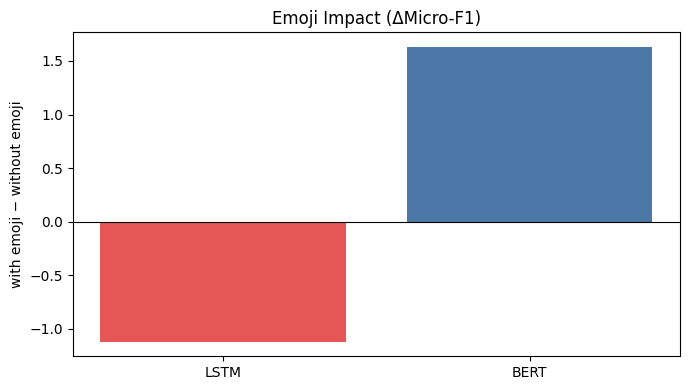

In [118]:
plt.figure(figsize=(7, 4))
colors = ['#4C78A8' if x > 0 else '#E45756' for x in emoji_impact['ΔMicro-F1']]
plt.bar(emoji_impact['Model'], emoji_impact['ΔMicro-F1'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Emoji Impact (ΔMicro-F1)')
plt.ylabel('with emoji − without emoji')
plt.tight_layout()
plt.show()

## Step 18 — Per-emotion emoji impact

In [119]:
per_emo_rows = []
for model_name in ['LSTM', 'BERT']:
    for emo in emotion_labels:
        f1_no = all_results[model_name]['no_emoji']['per_class_f1'][emo]
        f1_yes = all_results[model_name]['with_emoji']['per_class_f1'][emo]
        per_emo_rows.append({
            'Emotion': emo, 'Model': model_name,
            'F1 no emoji': round(f1_no * 100, 2),
            'F1 with emoji': round(f1_yes * 100, 2),
            'ΔF1': round((f1_yes - f1_no) * 100, 2),
        })
per_emotion_df = pd.DataFrame(per_emo_rows)
per_emotion_df.pivot_table(index='Emotion', columns='Model', values='ΔF1').assign(
    Mean=lambda d: d.mean(axis=1)
).sort_values('Mean', ascending=False)

Model,BERT,LSTM,Mean
Emotion,,,
sadness,21.01,-0.45,10.280
joy,3.18,2.61,2.895
disgust,4.28,0.61,2.445
pessimism,4.35,-2.72,0.815
fear,5.38,-5.31,0.035
trust,1.46,-2.59,-0.565
love,0.61,-2.83,-1.110
optimism,-0.55,-2.04,-1.295
anger,-2.77,-2.82,-2.795


## Step 19 — Confusion matrices

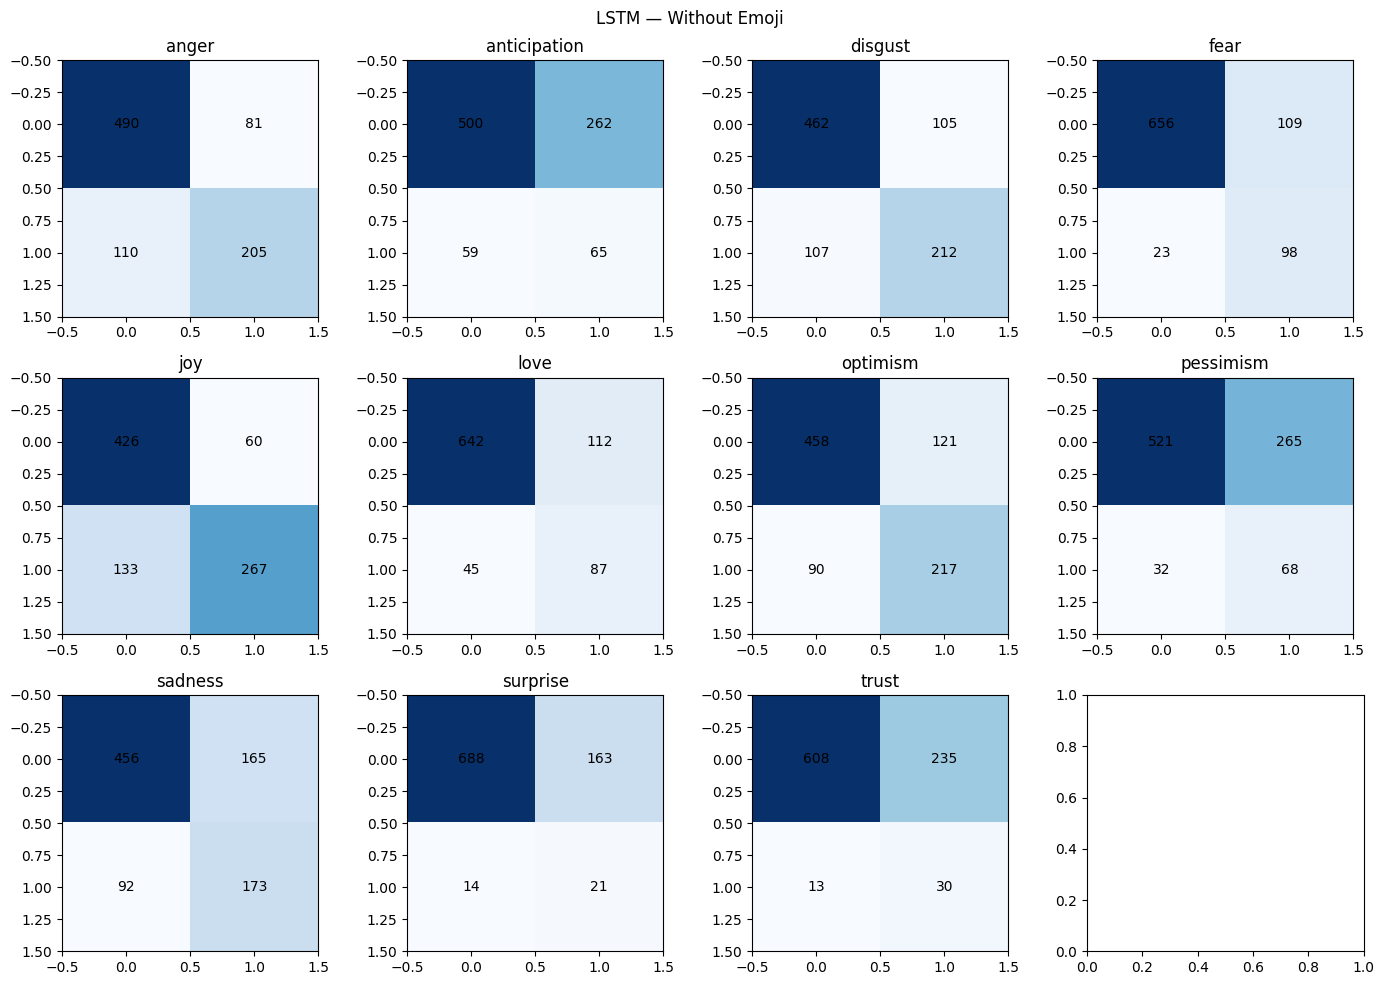

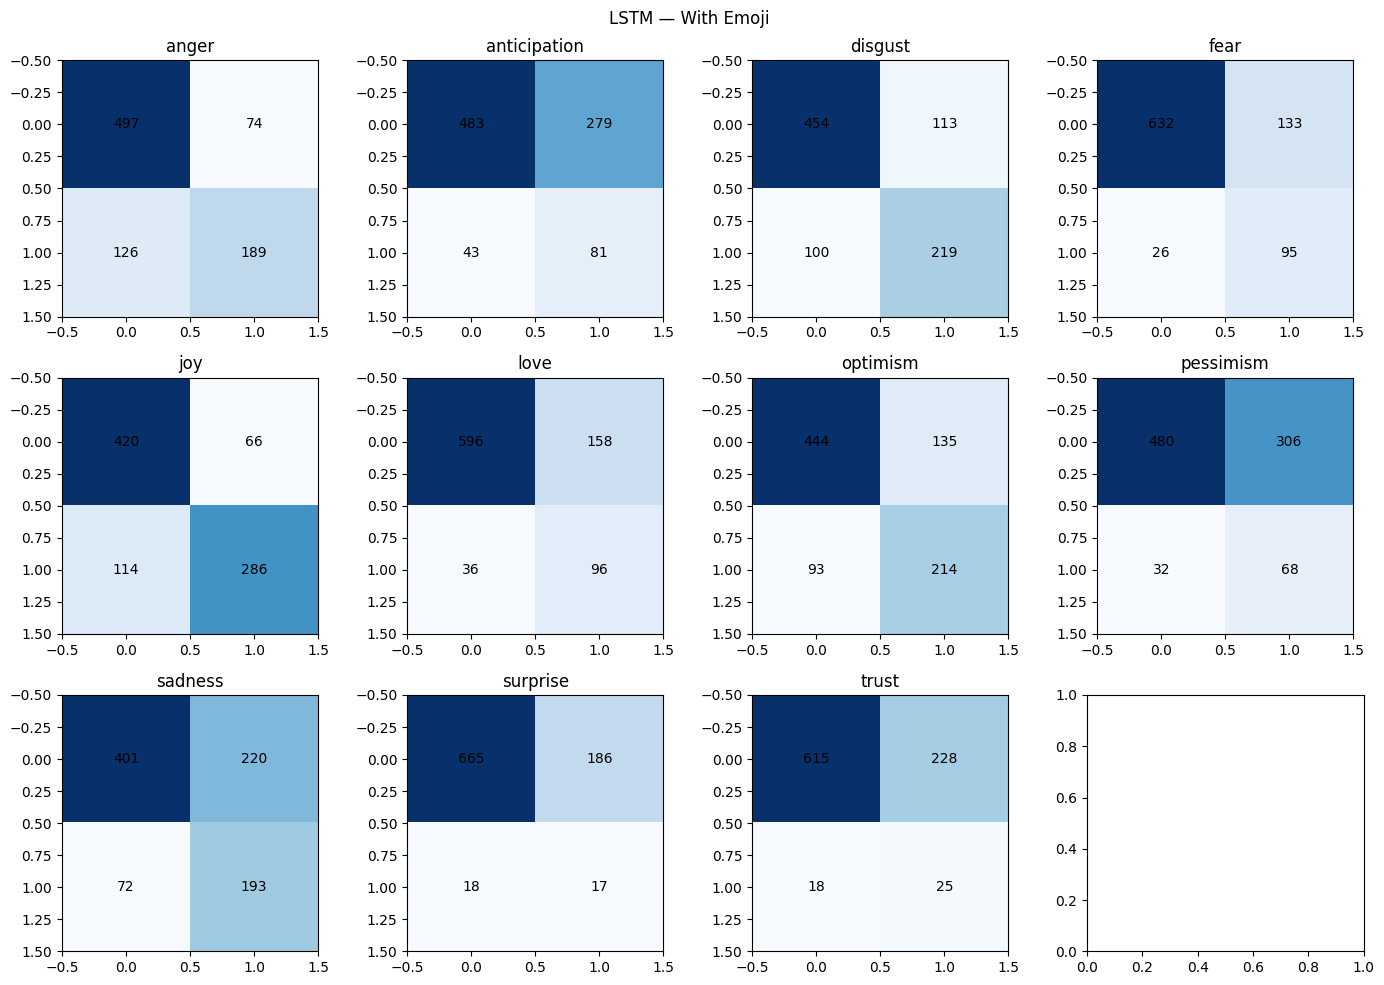

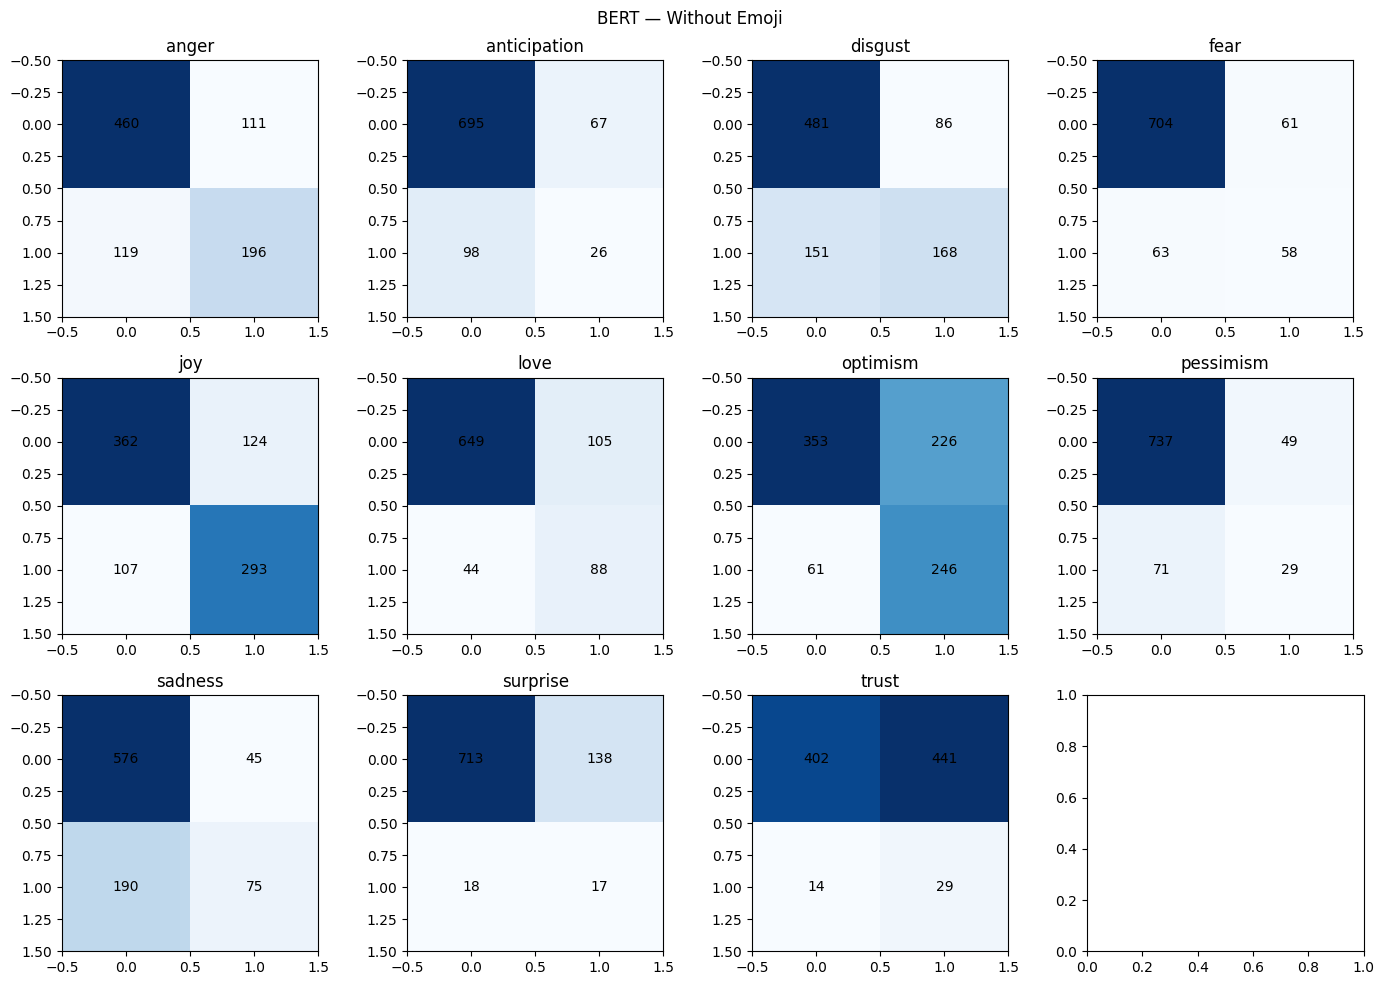

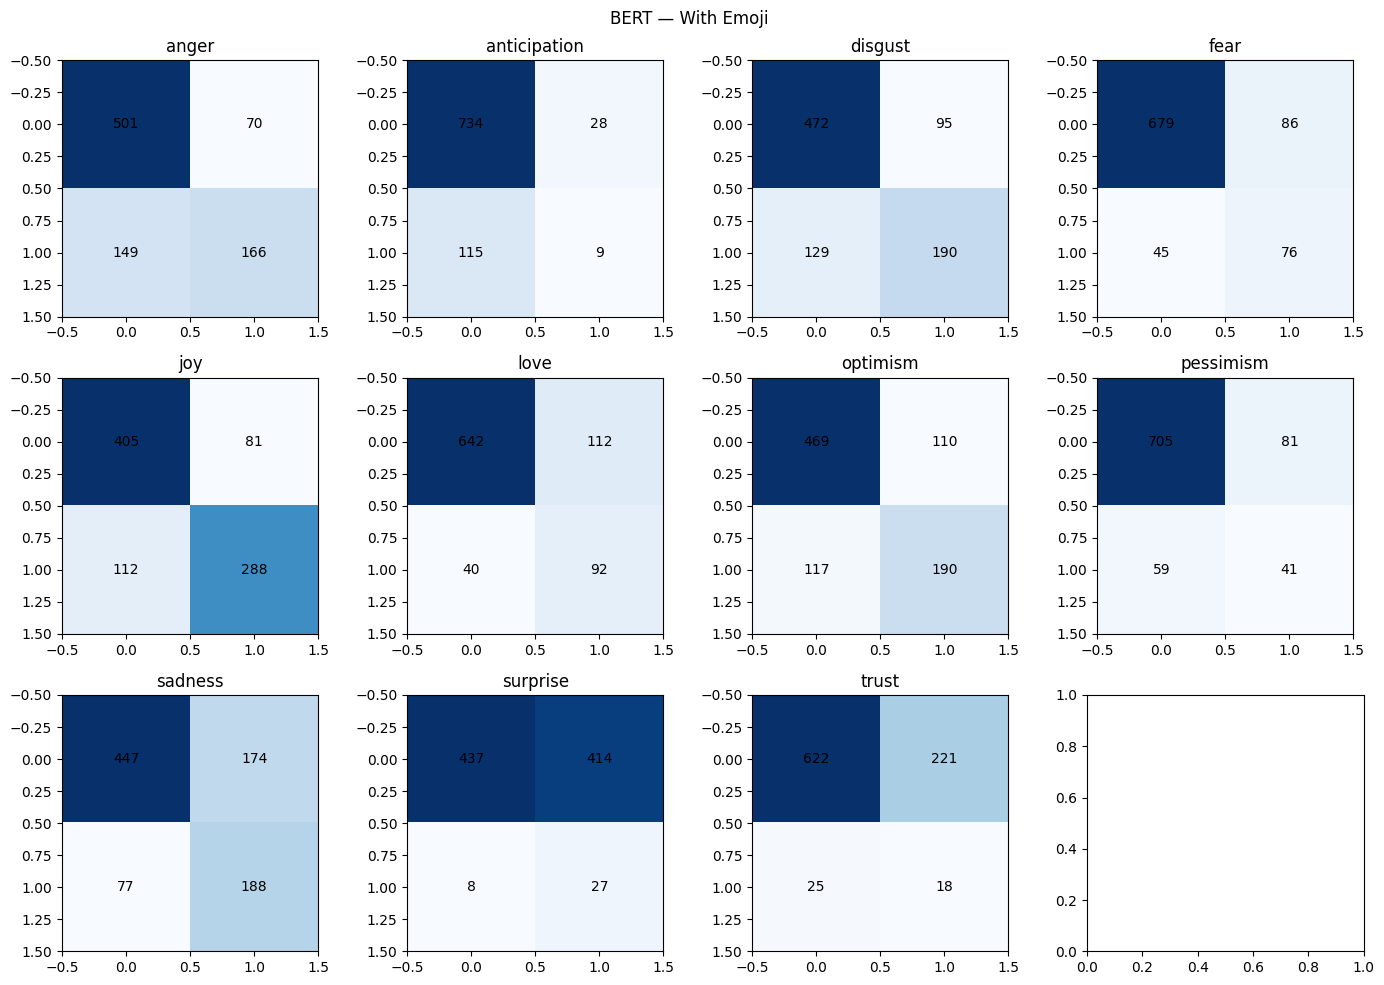

In [120]:
def plot_cm(model_name, track_key, track_label):
    cms = all_results[model_name][track_key]['confusion_matrices']
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for i, emo in enumerate(emotion_labels):
        ax = axes.flatten()[i]
        cm = cms[emo]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(emo)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha='center', va='center')
    fig.suptitle(f'{model_name} — {track_label}')
    plt.tight_layout()
    plt.show()

for model_name in ['LSTM', 'BERT']:
    for track_key, _, track_label in TRACKS:
        plot_cm(model_name, track_key, track_label)

## Step 20 — ROC curves (all models and tracks)

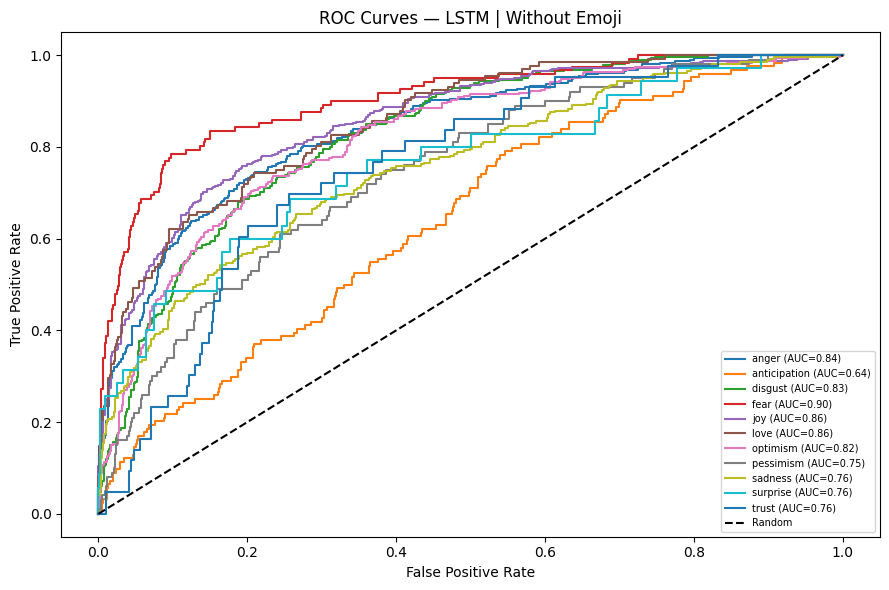

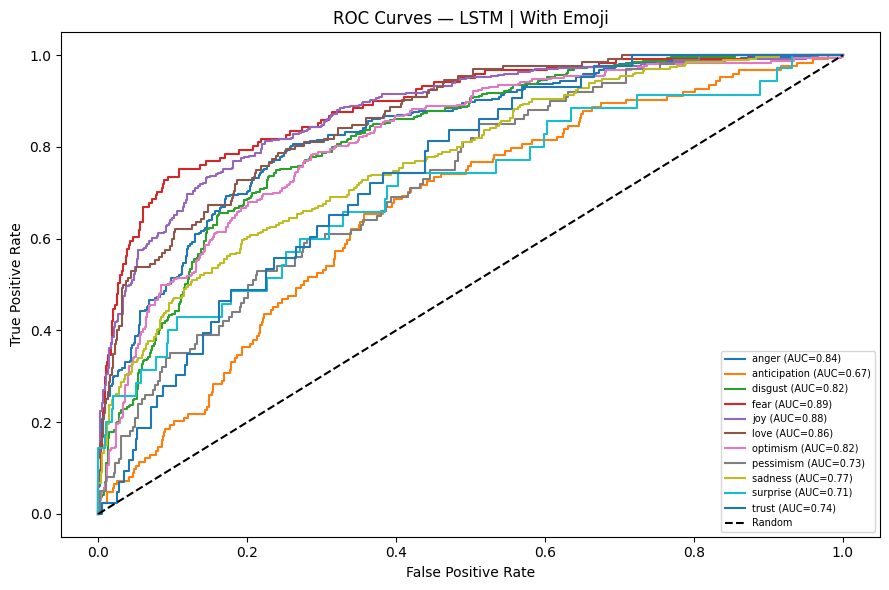

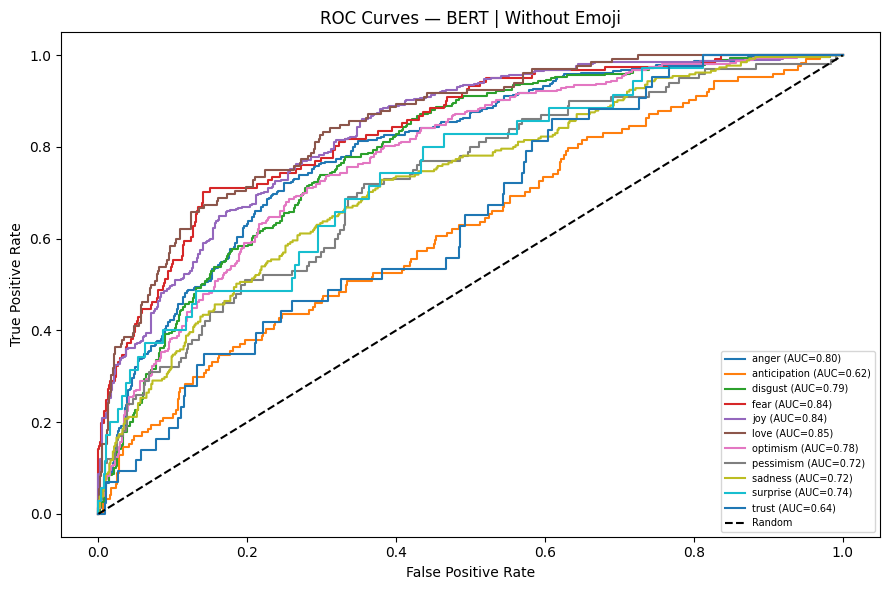

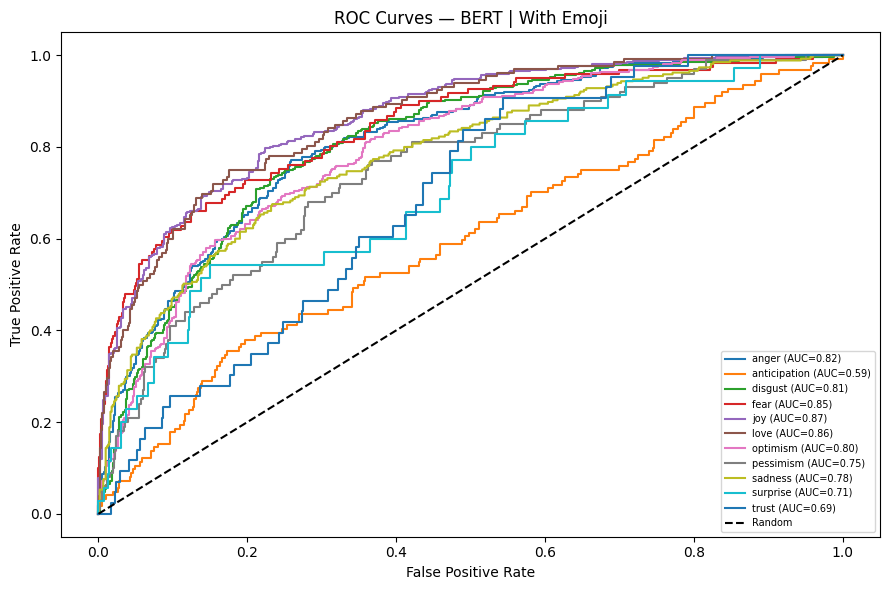

In [121]:
def plot_roc(model_name, track_key, track_label):
    roc_data = all_results[model_name][track_key]['roc_auc']
    if not roc_data:
        print(f'No ROC data for {model_name} | {track_label}')
        return
    plt.figure(figsize=(9, 6))
    for lbl, curve in roc_data.items():
        plt.plot(curve['fpr'], curve['tpr'], label=f"{lbl} (AUC={curve['auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title(f'ROC Curves — {model_name} | {track_label}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(fontsize=7, loc='lower right')
    plt.tight_layout()
    plt.show()

for model_name in ['LSTM', 'BERT']:
    for track_key, _, track_label in TRACKS:
        plot_roc(model_name, track_key, track_label)

## Step 21 — Explainable AI: confusion matrix interpretation

In [122]:
for model_name in ['LSTM', 'BERT']:
    for track_key, _, track_label in TRACKS:
        print(f"\n{'='*60}\n{model_name} | {track_label}\n{'='*60}")
        for emo in emotion_labels:
            tn, fp, fn, tp = all_results[model_name][track_key]['confusion_matrices'][emo].ravel()
            print(f"  {emo:<14} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")


LSTM | Without Emoji
  anger          TP=205 FP= 81 FN=110 TN=490
  anticipation   TP= 65 FP=262 FN= 59 TN=500
  disgust        TP=212 FP=105 FN=107 TN=462
  fear           TP= 98 FP=109 FN= 23 TN=656
  joy            TP=267 FP= 60 FN=133 TN=426
  love           TP= 87 FP=112 FN= 45 TN=642
  optimism       TP=217 FP=121 FN= 90 TN=458
  pessimism      TP= 68 FP=265 FN= 32 TN=521
  sadness        TP=173 FP=165 FN= 92 TN=456
  surprise       TP= 21 FP=163 FN= 14 TN=688
  trust          TP= 30 FP=235 FN= 13 TN=608

LSTM | With Emoji
  anger          TP=189 FP= 74 FN=126 TN=497
  anticipation   TP= 81 FP=279 FN= 43 TN=483
  disgust        TP=219 FP=113 FN=100 TN=454
  fear           TP= 95 FP=133 FN= 26 TN=632
  joy            TP=286 FP= 66 FN=114 TN=420
  love           TP= 96 FP=158 FN= 36 TN=596
  optimism       TP=214 FP=135 FN= 93 TN=444
  pessimism      TP= 68 FP=306 FN= 32 TN=480
  sadness        TP=193 FP=220 FN= 72 TN=401
  surprise       TP= 17 FP=186 FN= 18 TN=665
  trust       

## Step 22 — Save all results

In [123]:
summary = {}
for model_name in ['LSTM', 'BERT']:
    summary[model_name] = {
        'no_emoji_micro_f1': float(all_results[model_name]['no_emoji']['micro_f1']),
        'with_emoji_micro_f1': float(all_results[model_name]['with_emoji']['micro_f1']),
        'delta_micro_f1': float(all_results[model_name]['delta_micro_f1']),
        'best_config_no_emoji': all_results[model_name]['no_emoji']['best_params'],
        'best_config_with_emoji': all_results[model_name]['with_emoji']['best_params'],
    }

with open(os.path.join(results_dir, 'emoji_impact_results.json'), 'w') as f:
    json.dump(summary, f, indent=2)

results_table.to_csv(os.path.join(results_dir, 'results_table.csv'), index=False)
emoji_impact.to_csv(os.path.join(results_dir, 'emoji_impact.csv'), index=False)
per_emotion_df.to_csv(os.path.join(results_dir, 'per_emotion_impact.csv'), index=False)
tuning_results.to_csv(os.path.join(results_dir, 'hyperparameter_search.csv'), index=False)

print('Results saved to:', results_dir)
print('Cleaned data in:', cleaned_dir)

Results saved to: /kaggle/working/results
Cleaned data in: /kaggle/working/cleaned_data
